# CBR Legal Case Retrieval System

Nama : Ach Sofyan Daynur
NIM : 202110370311155

Implementasi Case-Based Reasoning (CBR) untuk Retrieval Kasus Hukum Menggunakan TF-IDF dan Cosine Similarity

# 01 Data Preparation

## CBR Legal Case Retrieval System

Tahap ini bertujuan untuk:

1. Mengakses dataset putusan hukum
2. Mengonversi PDF menjadi TXT
3. Membentuk dataset kasus
4. Menyimpan hasil ke cases.csv

Cell 2 — Import Library

In [4]:
import os
import pandas as pd

Cell 3 — Masuk ke Folder Project

In [5]:
%cd /content/CBR-Legal-Case

/content/CBR-Legal-Case


Cell 4 — Cek Struktur Folder

In [6]:
!find data -type f

data/results/predictions.csv
data/eval/retrieval_metrics.csv
data/eval/queries.json
data/eval/prediction_metrics.csv
data/raw/PUTUSAN-PUTUSAN/PUTUSAN 1.pdf
data/raw/PUTUSAN-PUTUSAN/PUTUSAN 3.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 22.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 26.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 15.pdf
data/raw/PUTUSAN-PUTUSAN/PUTUSAN 2.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 16.pdf
data/raw/PUTUSAN-PUTUSAN/PUTUSAN 6.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 11.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 30.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 9.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 19.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 28.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 10.pdf
data/raw/PUTUSAN-PUTUSAN/PUTUSAN 5.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 8.pdf
data/raw/PUTUSAN-PUTUSAN/PUTUSAN 4.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 23.pdf
data/raw/PUTUSAN-PUTUSAN/PUTUSAN 7.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 13.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 18.pdf
data/raw/PUTUSAN-PUTUSAN/putusan 24.pdf
data/raw/PUT

Tujuannya menunjukkan:

30 PDF
30 TXT
cases.csv

Cell 5 — Hitung Jumlah PDF

In [7]:
pdf_folder = "data/raw/PUTUSAN-PUTUSAN"

pdf_files = [
    f for f in os.listdir(pdf_folder)
    if f.endswith(".pdf")
]

print("Jumlah PDF :", len(pdf_files))

Jumlah PDF : 30


Cell 6 — Hitung Jumlah TXT

In [8]:
txt_folder = "data/raw/text"

txt_files = [
    f for f in os.listdir(txt_folder)
    if f.endswith(".txt")
]

print("Jumlah TXT :", len(txt_files))

Jumlah TXT : 30


Cell 7 — Load Dataset Cases

In [9]:
cases = pd.read_csv(
    "data/processed/cases.csv"
)

print("Jumlah kasus:", len(cases))

cases.head()

Jumlah kasus: 30


,case_id,text,nomor_putusan,tahun,pengadilan,jenis_perkara,pihak,pasal,ringkasan_fakta
0,putusan 11,hkama\nahkamah Agung Repub\nahkamah Agung Repu...,961/PID.SUS/2026/PT,2026,Pengadilan Tinggi Surabaya,Pidana Khusus,MOHAMMAD BEDRUN BIN SAMHERI,"Pasal 609, Pasal 114, pasal 114, pasal 14",Terdakwa diajukan ke persidangan oleh Kejaksaa...
1,putusan 8,hkama\nahkamah Agung Repub\nahkamah Agung Repu...,296/PID.SUS/2026/PT,2026,Tidak ditemukan,Pidana Khusus,ISKANDAR AK BIN ABU KOSIM,"Pasal 609, Pasal 25, pasal 80, Pasal\n609, Pas...","Penahanan oleh: 1. Penyidik, sejak tanggal 3 S..."
2,putusan 28,hkama\nahkamah Agung Repub\nahkamah Agung Repu...,99/Pid,Tidak ditemukan,Tidak ditemukan,Tidak diketahui,Tidak ditemukan,"Pasal\n114, Pasal 132, Pasal 112",Terdakwa diajukan ke persidangan oleh Penuntut...
3,putusan 20,hkama\nahkamah Agung Repub\nahkamah Agung Repu...,53/,Tidak ditemukan,Tidak ditemukan,Pidana Khusus,Tidak ditemukan,"Pasal 112, Pasal 127, Pasal 114","17 Desa Batu Mareah, Kecamatan Sirimau, Kota A..."
4,putusan 18,hkama\nahkamah Agung Repub\nahkamah Agung Repu...,2281,Tidak ditemukan,Tidak ditemukan,Pidana Khusus,Tidak ditemukan,"Pasal\n114, Pasal 132, Pasal 127, Pasal\n112",a : Islam ; Pekerjaan : Wiraswasta ; Terdakwa ...


dan tampil 5 baris pertama.

Cell 8 — Informasi Dataset

In [10]:
cases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   case_id          30 non-null     object
 1   text             30 non-null     object
 2   nomor_putusan    30 non-null     object
 3   tahun            30 non-null     object
 4   pengadilan       30 non-null     object
 5   jenis_perkara    30 non-null     object
 6   pihak            30 non-null     object
 7   pasal            30 non-null     object
 8   ringkasan_fakta  30 non-null     object
dtypes: object(9)
memory usage: 2.2+ KB


Cell 9 — Cek Missing Value

In [11]:
cases.isnull().sum()

,0
case_id,0
text,0
nomor_putusan,0
tahun,0
pengadilan,0
jenis_perkara,0
pihak,0
pasal,0
ringkasan_fakta,0


Cell 10 — Statistik Panjang Dokumen

In [12]:
cases["jumlah_kata"] = (
    cases["text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

cases["jumlah_kata"].describe()

,jumlah_kata
count,30.000000
mean,10376.366667
std,7978.216189
min,2186.000000
25%,5075.750000
50%,7828.500000
75%,12293.750000
max,38270.000000


Cell 11 — Visualisasi Panjang Dokumen

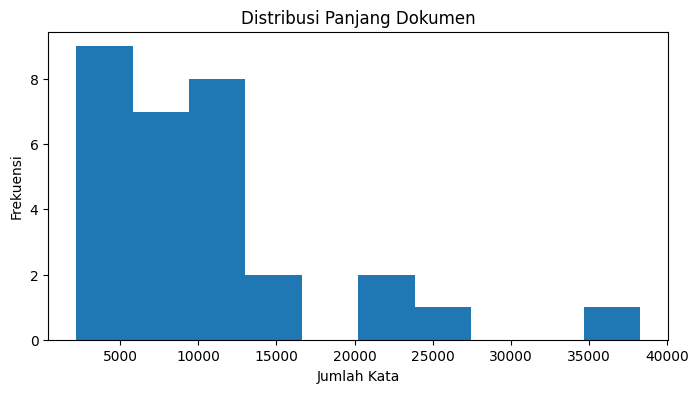

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(
    cases["jumlah_kata"],
    bins=10
)

plt.title("Distribusi Panjang Dokumen")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")

plt.show()

Cell 12 — Kesimpulan

## Hasil Tahap Data Preparation

- Dataset terdiri dari 30 putusan hukum
- Seluruh PDF berhasil dikonversi menjadi TXT
- Dataset berhasil disimpan ke cases.csv
- Tidak ditemukan missing value
- Dataset siap digunakan pada tahap representasi kasus